In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
pd.set_option('display.float_format', '{:,.1f}'.format)

In [2]:
df = pd.read_csv('airport_traffic_merged.csv')

In [3]:
selected_airports = (
    df.groupby(["APT_NAME"])["FLT_TOT_1"].sum()
    .reset_index()
    .sort_values("FLT_TOT_1", ascending=False)
    .head(25)
)

[]

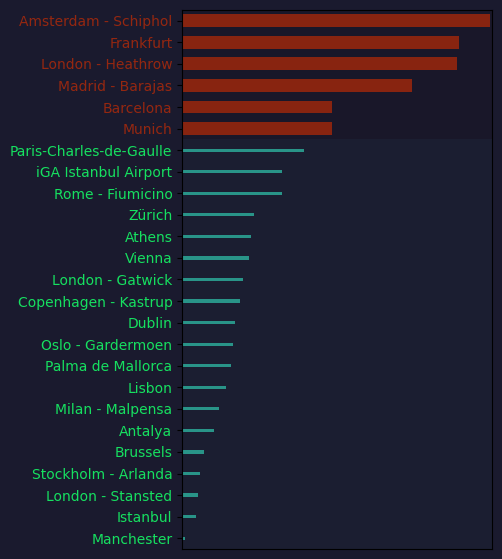

In [ ]:
# Black hat
fig, ax = plt.subplots(figsize=(4, 7))

# Sfondo scuro
fig.set_facecolor("#1a1a2e")
ax.set_facecolor("#1a1a2e")

labels = [row.APT_NAME for _, row in selected_airports.iterrows()]
values = (selected_airports["FLT_TOT_1"] / 1e6).values
colors = ["#C42E08BB" if i < 6 else "#2A9D8F" for i in range(len(selected_airports))]

# Crea le barre una per una con altezze diverse
for i, (label, val) in enumerate(zip(labels, values)):
    h = 0.6 if i < 6 else 0.15
    ax.barh(label, val, color=colors[i], edgecolor="none", height=h)

#imposta colori diversi per le etichette
for i, label in enumerate(ax.get_yticklabels()):
    if i < 6:
        label.set_color("#C22C06BB")
    else:
        label.set_color("#16E060")


# Sfondo per i primi 5 elementi
ax.axhspan(-0.5, 5.5, facecolor="#110501", alpha=0.1)

# Sfondo per gli altri
ax.axhspan(5.5, len(selected_airports) - 0.5, facecolor="#264653", alpha=0.1)        

#mette linea verticale
#ax.axvline(x = 1.86, color = 'red', linestyle= '--')


#ax.set_xlim(1.1, auto = False, emit = False)
ax.set_ylim(-0.5, len(selected_airports) - 0.5)
ax.invert_yaxis()

ax.set_xlim( 1.1, 3)  # imposta il range che viene visualizzato sulle x
ax.set_xticks([]) # imposta gli elementi della scala che si possono mettere sulle x

